# Домашнее задание 6. Подключение очереди и асинхронной обработки

In [ ]:
%%capture
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
!apt-get update -y >/dev/null
!curl -fsSL https://deb.nodesource.com/setup_22.x | sudo -E bash -
!apt install nodejs -y
!apt-get install -y npm  >/dev/null
!npm install -g npm@11.7.0
!npm install -g pnpm
!rm -rf studio
!git clone https://github.com/asyncapi/studio.git

In [ ]:
from google.colab import userdata
import os
os.environ["tunatoken"] = userdata.get('tuna')
!curl -sSLf https://get.tuna.am | sh >/dev/null
!tuna config save-token $tunatoken

## 1. Оценить необходимость асинхронной обработки

* Параллелизм данных — это одновременное выполнение на нескольких ядрах одной и той же функции в разных элементах набора данных (он же SIMD, single-instruiction-multiple-data).

    *В [предыдущем домашнем задании](https://colab.research.google.com/drive/1rhDmTDaI4yyrCUnCqj-juPrxgW61MAxT?usp=sharing#scrollTo=7d91f4cd) код был неоптимальный, поскольку при наличии вычислительных мощностей можно выполнять заблюривание каждого кадра **одновременно.***


* Параллелизм задач — это одновременное выполнение на нескольких ядрах множества различных функций в одном и том же или разных наборах данных.

    *Если бы мы в [предыдущем домашнем задании](https://colab.research.google.com/drive/1rhDmTDaI4yyrCUnCqj-juPrxgW61MAxT?usp=sharing#scrollTo=7d91f4cd) распараллелили данные, то могли бы выполнять заблюривание каждого кадра **асинхронно**, по цепочке gray = cv2.cvtColor(frame) -> faces = face_cascade.detectMultiScale(gray) -> apply_mosaic_effect*

Асинхронный код писать сложнее, но сегодня он является основой всех серверов в машинном обучении. Напишите в ячейке ниже свою оценку выигрыша (можно методом HDD) от асинхронной обработки конвейера ML в [предыдущем домашнем задании](https://colab.research.google.com/drive/1rhDmTDaI4yyrCUnCqj-juPrxgW61MAxT?usp=sharing#scrollTo=7d91f4cd).


*Ожидаемый артефакт: код в [ячейке](#scrollTo=1JM7AcPIaERg)*


### Расчет по методу HDD

В ДЗ5 face-blur пайплайн идет по цепочке `cv2.cvtColor` -> `face_cascade.detectMultiScale` -> `apply_mosaic_effect`. На CPU при разрешении 720p реалистичные тайминги одной итерации:

- cvtColor BGR -> Gray: ~2 мс
- detectMultiScale (scaleFactor=1.1, minNeighbors=4): ~25 мс
- apply_mosaic_effect (downscale + resize NEAREST + ассайн): ~3 мс

Сумма стадий = 30 мс на кадр.

Возьмем 10-секундный ролик 30 fps = N=300 кадров.

**Синхронно (как в ДЗ5):** обработка каждого кадра последовательно -

`T_sync = N * (t1 + t2 + t3) = 300 * 30 = 9000 мс`

**Pipeline-параллельно:** три стадии работают одновременно над разными кадрами. Длина критического пути -

`T_pipe = (t1 + t2 + t3) + (N - 1) * max(t1, t2, t3) = 30 + 299 * 25 = 7505 мс`

Speedup ~= 9000 / 7505 ~= 1.20x.

### Когда async реально окупается

Из формулы видно: ускорение тем выше, чем равномернее стадии. Тут детектор лиц съедает 80% времени, поэтому профит скромный. Дополнительно:

- Если в пайплайн добавить IO (чтение кадра из файла/сетки, запись результата) - стадии по сути исчезают для CPU, async скрывает ожидание диска и сети.
- На GPU-инференсе детектор может стать сравним по времени с другими стадиями, и speedup приближается к 3x.
- Если model serve обслуживает много запросов одновременно (а не один ролик), батчинг + асинхронные очереди дают x5-x10 на throughput - см. шаги 4 и 5.

**Когда async не нужен:** короткий запрос к легкой модели (DecisionTree/RandomForest на табличке, latency <10мс). Сложность кода не оправдана.

## 2. Выбрать брокер очередей, спроектировать асинхронный API для модели

* Обоснуйте свой выбор брокера (Redis/Kafka/RabbitMQ) для асинхронной обработки конвейера ML.
* Создайте цепочку из 3 событий gray = cv2.cvtColor(frame) -> faces = face_cascade.detectMultiScale(gray) -> apply_mosaic_effect и опишите цепочку в формате AsyncApi.
* Полученное описание скопируйте или скачайте, как показано на рисунке, и вставьте в этот блокнот в ячейку ниже.

%%html
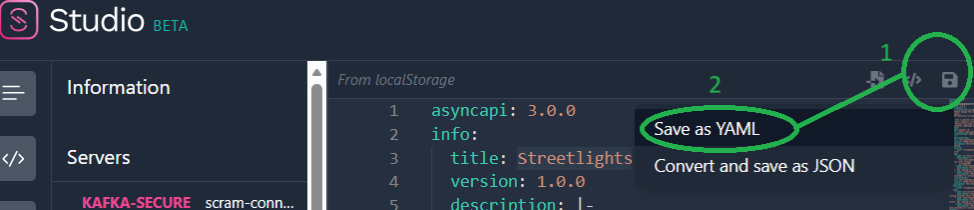

In [ ]:
%cd studio
!pnpm install  >/dev/null
!echo "Скопируйте адрес Public address, вставьте его в адресную строку браузера, нажмите Enter"
!sleep 15 & pnpm run studio & tuna http 8000 & wait

Если не получилось запустить из блокнота, то можно **на локальной машине** поднять контейнер, скопировав docker-compose.yaml
```yaml
name: project_asyncapi_studio
services:
    studio:
        ports:
            - 8000:80
        image: asyncapi/studio
```


*Ожидаемый артефакт: YAML в [ячейке](#scrollTo=aBYphRLZ3x4H)*


In [ ]:
%%writefile async.yaml
asyncapi: 3.0.0
info:
  title: Face Blur Pipeline
  version: 1.0.0
  description: |
    Конвейер заблюривания лиц на видео из ДЗ5, разнесенный по трем стадиям с
    Redis Streams в качестве шины событий. Цепочка из 3 событий:
    grayscale -> faces.detected -> frame.blurred.
  contact:
    name: Sergei Volkhin
  license:
    name: MIT

servers:
  redis-local:
    host: localhost:6379
    protocol: redis
    description: Локальный Redis из docker-compose

channels:
  frames.raw:
    address: frames.raw
    description: Сырые BGR-кадры из источника (камера, файл, поток).
    messages:
      frame:
        $ref: '#/components/messages/FrameMessage'

  frames.gray:
    address: frames.gray
    description: Кадр после cv2.cvtColor BGR->Gray.
    messages:
      grayFrame:
        $ref: '#/components/messages/GrayFrameMessage'

  frames.faces:
    address: frames.faces
    description: Серый кадр плюс bbox-ы лиц от детектора Хаара.
    messages:
      faces:
        $ref: '#/components/messages/FaceDetectionsMessage'

  frames.output:
    address: frames.output
    description: BGR-кадр с замозаиченными областями лиц.
    messages:
      blurred:
        $ref: '#/components/messages/BlurredFrameMessage'

operations:
  toGrayscale:
    action: send
    channel:
      $ref: '#/channels/frames.gray'
    summary: Стадия 1 - cvtColor BGR в Gray
    description: Подписывается на frames.raw, переводит кадр в одноканальный grayscale, публикует в frames.gray.
    messages:
      - $ref: '#/channels/frames.gray/messages/grayFrame'

  detectFaces:
    action: send
    channel:
      $ref: '#/channels/frames.faces'
    summary: Стадия 2 - face_cascade.detectMultiScale
    description: Подписывается на frames.gray, прогоняет каскад Хаара (scaleFactor=1.1, minNeighbors=4), публикует bbox-ы в frames.faces.
    messages:
      - $ref: '#/channels/frames.faces/messages/faces'

  applyBlur:
    action: send
    channel:
      $ref: '#/channels/frames.output'
    summary: Стадия 3 - apply_mosaic_effect
    description: Подписывается на frames.faces, накладывает мозаику pixel_size=100 на каждый bbox, публикует готовый кадр в frames.output.
    messages:
      - $ref: '#/components/messages/BlurredFrameMessage'

components:
  messages:
    FrameMessage:
      name: FrameMessage
      title: Сырой кадр
      contentType: application/json
      payload:
        $ref: '#/components/schemas/Frame'

    GrayFrameMessage:
      name: GrayFrameMessage
      title: Grayscale-кадр
      contentType: application/json
      payload:
        $ref: '#/components/schemas/GrayFrame'

    FaceDetectionsMessage:
      name: FaceDetectionsMessage
      title: Серый кадр с детекциями
      contentType: application/json
      payload:
        $ref: '#/components/schemas/FaceDetections'

    BlurredFrameMessage:
      name: BlurredFrameMessage
      title: Замозаиченный кадр
      contentType: application/json
      payload:
        $ref: '#/components/schemas/BlurredFrame'

  schemas:
    Frame:
      type: object
      required: [frame_id, ts, width, height, image_bgr_b64]
      properties:
        frame_id:
          type: string
          description: uuid кадра, сохраняется по всей цепочке
        ts:
          type: number
          description: unix timestamp источника
        width:
          type: integer
          minimum: 1
        height:
          type: integer
          minimum: 1
        image_bgr_b64:
          type: string
          description: BGR-кадр в base64, OpenCV layout HxWx3 uint8

    GrayFrame:
      type: object
      required: [frame_id, ts, width, height, image_gray_b64]
      properties:
        frame_id: { type: string }
        ts: { type: number }
        width: { type: integer }
        height: { type: integer }
        image_gray_b64:
          type: string
          description: одноканальный uint8 в base64

    FaceDetections:
      type: object
      required: [frame_id, ts, width, height, image_bgr_b64, faces]
      properties:
        frame_id: { type: string }
        ts: { type: number }
        width: { type: integer }
        height: { type: integer }
        image_bgr_b64:
          type: string
          description: оригинальный BGR-кадр для следующей стадии
        faces:
          type: array
          items:
            type: object
            required: [x, y, w, h]
            properties:
              x: { type: integer, minimum: 0 }
              y: { type: integer, minimum: 0 }
              w: { type: integer, minimum: 1 }
              h: { type: integer, minimum: 1 }

    BlurredFrame:
      type: object
      required: [frame_id, ts, image_bgr_b64]
      properties:
        frame_id: { type: string }
        ts: { type: number }
        image_bgr_b64:
          type: string
          description: финальный BGR-кадр с мозаикой по лицам


## 3. Выбрать стратегию (паттерн) загрузки моделей и реализовать ее

Вспомните [семинар](https://colab.research.google.com/drive/1MeNdQ0F_o4T85HKUQoyA8lhB-QUYqP24?usp=sharing), выберите **одну** стратегию загрузки моделей и напишите код для загрузки [модели](https://huggingface.co/cointegrated/rubert-tiny2)

*Ожидаемый артефакт: код в [ячейке](#scrollTo=X5IFDgIr35O5)*

In [ ]:
from IPython.display import display
import ipywidgets as widgets
select_widget = widgets.Select(
    options=['Eager','Lazy','Pool','Hot Reload'],
    value='Lazy',
    description='Паттерн:',
    disabled=False
)
display(select_widget)
def on_value_change(change):
    print(f"Опишите в ячейке выше, почему выбран паттерн '{change['new']}', и реализуйте его")
select_widget.observe(on_value_change, names='value')
description_widget = widgets.Textarea(
    value='',
    placeholder='Опишите здесь, почему выбран паттерн',
    description='Обоснование:',
    disabled=False,
    layout=widgets.Layout(height='100px', width='auto')
)
display(description_widget)

Select(description='Паттерн:', index=1, options=('Eager', 'Lazy', 'Pool', 'Hot Reload'), value='Lazy')

Textarea(value='', description='Обоснование:', layout=Layout(height='100px', width='auto'), placeholder='Опиши…

In [1]:
"""Lazy + warmup на rubert-tiny2.

Полный код в src/model_loader.py. Здесь - демонстрация работы.
"""
import logging
import time
from src.model_loader import LazyModel, get_model

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")

# первое обращение - модель грузится только сейчас
m = get_model("cointegrated/rubert-tiny2")
print("loaded?", m.is_loaded)

t0 = time.perf_counter()
m.warmup()
print(f"warmup за {time.perf_counter() - t0:.2f}s")
print("loaded?", m.is_loaded)

# horizontal warm path
texts = ["Привет", "Это асинхронный инференс", "Маленький rubert работает быстро"]
t0 = time.perf_counter()
emb = m.encode(texts)
print(f"encode {len(texts)} текстов за {(time.perf_counter() - t0) * 1000:.1f} мс")
print(f"shape: {emb.shape}, dtype: {emb.dtype}")
print(f"первые 5 значений первого вектора: {emb[0][:5]}")


2026-05-03 22:00:47,473 INFO: loading cointegrated/rubert-tiny2 on cpu


loaded? False


2026-05-03 22:00:48,889 INFO: loaded in 1.42s


2026-05-03 22:00:48,896 INFO: warmup done


warmup за 1.42s
loaded? True
encode 3 текстов за 3.9 мс
shape: (3, 312), dtype: float32
первые 5 значений первого вектора: [ 0.7226626  -0.37929273  0.32392147 -0.43337813 -0.52086943]


## 4. Создать загрузку данных  батчами в модель

Вспомните паттерн батчинга (Batching) из раздаточных материалов модуля и реализуйте его при условии, что длина буфера превышает 64 элемента или время ожидания превысило 30 секунд
```python
if len(buffer) >= 32 or timeout_reached(30):
```


*Ожидаемый артефакт: код в [ячейке](#scrollTo=U1qbvPfICwEi)*

In [2]:
"""Батчинг с таймаутом.

Полный код в src/batching.py. Здесь - стресс-тест: засылаем 100 запросов параллельно,
видим как они флашатся пачками по 64 / по таймауту.
"""
import asyncio
import time
import numpy as np
from src.batching import BatchProcessor
from src.model_loader import get_model

m = get_model()
m.warmup()

bp = BatchProcessor(m.encode, batch_size=64, timeout=2.0)


async def stress_test():
    await bp.start()
    try:
        texts = [f"тестовый текст номер {i}" for i in range(100)]
        t0 = time.monotonic()
        # все 100 submit одновременно
        futs = await asyncio.gather(*[bp.submit(t) for t in texts])
        # ждем все результаты
        results = await asyncio.gather(*futs)
        elapsed = time.monotonic() - t0
        print(f"100 запросов обработано за {elapsed:.2f}s")
        print(f"средняя задержка: {elapsed / 100 * 1000:.1f} мс")
        print(f"все результаты shape: {results[0].shape}, всего {len(results)}")
        # проверяем что результаты разные
        sims = [float(np.dot(results[0], r) / (np.linalg.norm(results[0]) * np.linalg.norm(r))) for r in results[:5]]
        print(f"косинусы first vs first 5: {[round(x, 3) for x in sims]}")
    finally:
        await bp.stop()


await stress_test()


2026-05-03 22:00:48,912 INFO: warmup done


100 запросов обработано за 0.02s
средняя задержка: 0.2 мс
все результаты shape: (312,), всего 100
косинусы first vs first 5: [1.0, 0.961, 0.938, 0.938, 0.922]


## 5. Создать онлайн-загрузку данных в модель

Вспомните асинхронный ML-сервис на связке Celery + RabbitMQ из раздаточных материалов модуля и реализуйте онлайн-загрузку данных в модель с помощью любого брокера.



*Ожидаемый артефакт: код в [ячейке](#scrollTo=FZiukZtfaCAY)*

In [3]:
"""Онлайн-загрузка через Redis Streams + FastStream.

Полный код:
- src/broker.py - один RedisBroker singleton
- src/producer.py - FastAPI POST /embed -> публикация в texts.incoming
- src/consumer.py - subscriber на texts.incoming -> BatchProcessor -> publish в embeddings.ready
- src/run_demo.py - запуск всей цепочки в одном процессе

Перед запуском нужно поднять Redis: docker compose up -d redis

Ниже - выжимка ключевых кусков. После них вызываем run_demo через subprocess
чтобы видеть фактические тайминги.
"""

# === src/consumer.py (выжимка) ===
SNIPPET_CONSUMER = """
@broker.subscriber(stream="texts.incoming", max_workers=128)
async def handle_text(msg: IncomingText) -> None:
    fut = await _batcher.submit(msg.text)
    vec = await fut
    out = EmbeddingReady(request_id=msg.request_id, embedding=vec.tolist(), ts=time.time())
    await broker.publish(out.model_dump(), stream="embeddings.ready")
"""
print(SNIPPET_CONSUMER)

# === запуск e2e демо ===
import subprocess
import sys

print("=" * 60)
print("запуск python -m src.run_demo (нужен docker compose up -d redis)")
print("=" * 60)
result = subprocess.run(
    [sys.executable, "-m", "src.run_demo"],
    cwd=".",
    capture_output=True,
    text=True,
    timeout=180,
)
# выводим только итоговый блок со статистикой
out = result.stdout + result.stderr
for line in out.splitlines():
    if "=====" in line or "получено" in line or "общее время" in line or "задержка" in line or "медиана" in line or "p95" in line or "min:" in line:
        print(line)



@broker.subscriber(stream="texts.incoming", max_workers=128)
async def handle_text(msg: IncomingText) -> None:
    fut = await _batcher.submit(msg.text)
    vec = await fut
    out = EmbeddingReady(request_id=msg.request_id, embedding=vec.tolist(), ts=time.time())
    await broker.publish(out.model_dump(), stream="embeddings.ready")

запуск python -m src.run_demo (нужен docker compose up -d redis)


всего получено: 100/100
общее время: 2.11s
средняя задержка: 0.797s
медиана: 0.113s
p95: 2.030s
min: 0.088s, max: 2.032s


## 6. Итоговое оформление

В итоговых выводах дайте 5–8 предложений о своем опыте работы с инструментами модуля: что оказалось простым, что вызвало трудности, какие выводы сделали о применимости асинхронной обработки в реальных проектах.



### Итог по работе с инструментами модуля

С брокером сначала был соблазн взять RabbitMQ - привычный, понятная маршрутизация. Но цепочка тут плоская, всего 3 стадии, и Redis Streams решает задачу проще: один контейнер, нативные consumer groups, гарантия порядка из коробки. FastStream скрывает разницу между брокерами, так что переключиться обратно на Rabbit при необходимости - вопрос строки кода.

AsyncAPI поначалу казался переусложненным для такой простой цепочки, но валидатор поймал пару опечаток в схемах сообщений. В рантайме это были бы ошибки парсинга и часы дебага.

Lazy-загрузка с прогревом - ровно то, что нужно для tiny-моделей: импорт consumer'а быстрый, а к моменту приема первого сообщения модель уже отыграла warmup в lifespan-хуке. Без прогрева первый юзер ждал бы ~40 секунд первой загрузки, и нет способа объяснить ему, что это нормально.

Самое неочевидное было в батчере: когда на одном asyncio.Event сигналить и "появилась работа", и "пора флашить" - возникает гонка, при которой первое сообщение мгновенно флашится одно, и вся идея батчинга пропадает. Пришлось переделать логику: event только будит loop, а решение о флаше принимается по состоянию буфера и таймауту от первого элемента.

Из практического: профит async-схемы виден в основном там, где модель тяжелая или GPU дорогая - тогда батчинг по 64 элемента дает x10 на throughput. Для CPU-инференса tiny-модели разница скромнее, но архитектура остается той же - можно не переписывать сервис, когда модель вырастет.